# Netflix Subscriptions Forecasting using Python

Forecasting the number of subscriptions Netflix will achieve in a time period is a vital business practice that enables them to plan, strategize, and make data-driven decisions. It enhances operational efficiency, financial planning, and content strategy, ultimately contributing to their success and growth in the highly competitive streaming industry. If you want to learn how to forecast the number of subscriptions for a streaming service like Netflix, this article is for you. 

### Netflix Subscriptions Forecasting: Process We Can Follow
Using techniques like time series forecasting, Netflix can estimate the expected number of new subscribers in a given time period and better understand the growth potential of their business. Below is the process we can follow to forecast subscription counts for Netflix:

- Gather historical Netflix subscriptions growth data
- Preprocess and clean the data
- Explore and analyze time series patterns
- Choose a time series forecasting model (e.g., ARIMA, LSTM)
- Train the model using the training data
- Forecast future Netflix subscription counts

So the process for forecasting subscriptions for Netflix starts with collecting a dataset based on the historical growth of Netflix Subscribers. I found an ideal dataset for this task. You can download the dataset from https://amanxai.com/wp-content/uploads/2023/08/netflix-subscriptions-1.zip.


In the section below, I’ll take you through the task of Netflix Subscriptions Forecasting using Time Series Forecasting and the Python programming language.



In [20]:
import warnings
warnings.filterwarnings('ignore')


### Importing Necessay Python libraries

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objs as go
import plotly.express as px
import plotly.io as pio
pio.templates.default = "plotly_white"
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# reading the data
data = pd.read_csv('Netflix-Subscriptions.csv')


In [22]:
data.head()

,Time Period,Subscribers
0,01/04/2013,34240000
1,01/07/2013,35640000
2,01/10/2013,38010000
3,01/01/2014,41430000
4,01/04/2014,46130000


In [23]:
data['Time Period'] = pd.to_datetime(data['Time Period'], 
                                     format='%d/%m/%Y')
print(data.head())

  Time Period  Subscribers
0  2013-04-01     34240000
1  2013-07-01     35640000
2  2013-10-01     38010000
3  2014-01-01     41430000
4  2014-04-01     46130000


In [24]:
data.describe()


,Time Period,Subscribers
count,42,4.200000e+01
mean,2018-05-17 00:34:17.142857216,1.304243e+08
min,2013-04-01 00:00:00,3.424000e+07
25%,2015-10-24 00:00:00,6.722500e+07
50%,2018-05-16 12:00:00,1.216250e+08
75%,2020-12-09 00:00:00,2.015325e+08
max,2023-07-01 00:00:00,2.383900e+08
std,NaN,6.891896e+07


In [25]:
print(data.isnull().sum())    


Time Period    0
Subscribers    0
dtype: int64


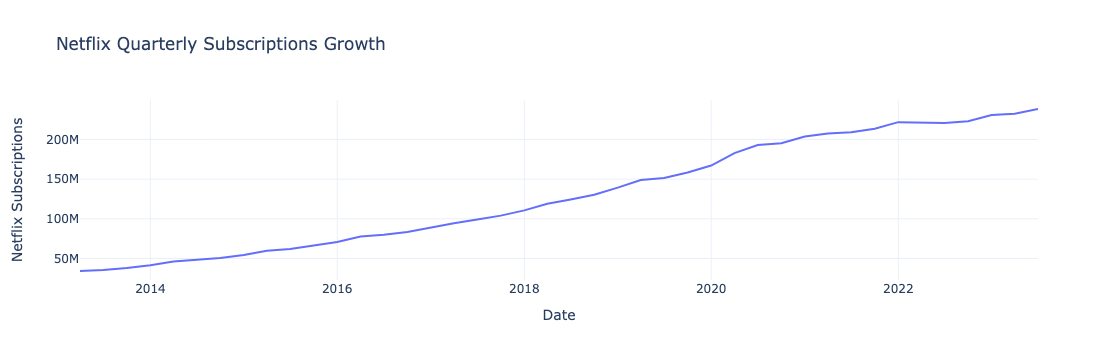

In [26]:
fig = go.Figure()
fig.add_trace(go.Scatter(x=data['Time Period'],
                         y=data['Subscribers'],
                         mode='lines', name='Subscribers'))
fig.update_layout(title='Netflix Quarterly Subscriptions Growth',
                  xaxis_title='Date',
                  yaxis_title='Netflix Subscriptions')
fig.show()

In the above graph, we can see that the growth of Netflix subscribers is not seasonal. So we can use a forecasting technique like ARIMA in this dataset.

Now let’s have a look at the quarterly growth rate of subscribers at Netflix:

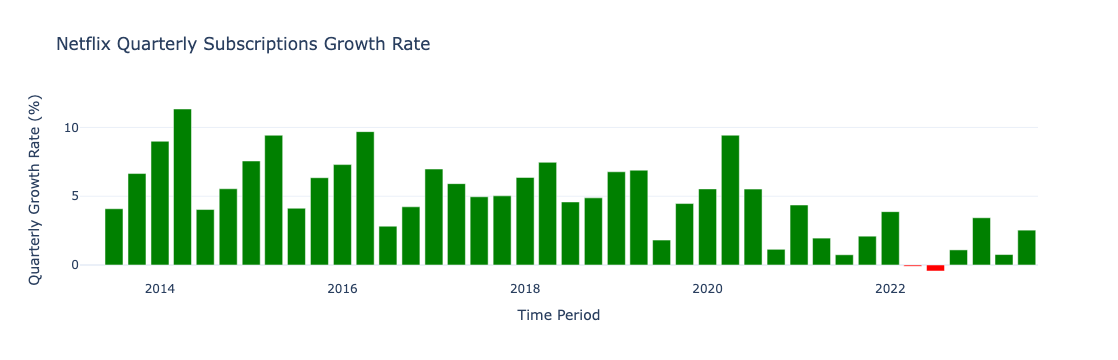

In [27]:
# Calculate the quarterly growth rate
data['Quarterly Growth Rate'] = data['Subscribers'].pct_change() * 100

# Create a new column for bar color (green for positive growth, red for negative growth)
data['Bar Color'] = data['Quarterly Growth Rate'].apply(lambda x: 'green' if x > 0 else 'red')

# Plot the quarterly growth rate using bar graphs
fig = go.Figure()
fig.add_trace(go.Bar(
    x=data['Time Period'],
    y=data['Quarterly Growth Rate'],
    marker_color=data['Bar Color'],
    name='Quarterly Growth Rate'
))
fig.update_layout(title='Netflix Quarterly Subscriptions Growth Rate',
                  xaxis_title='Time Period',
                  yaxis_title='Quarterly Growth Rate (%)')
fig.show()

Now let’s have a look at the yearly growth rate:

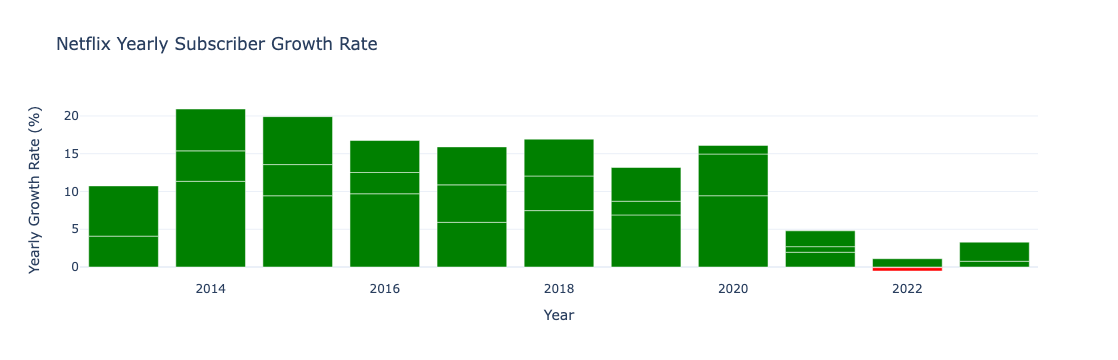

In [28]:
# Calculate the yearly growth rate
data['Year'] = data['Time Period'].dt.year
yearly_growth = data.groupby('Year')['Subscribers'].pct_change().fillna(0) * 100

# Create a new column for bar color (green for positive growth, red for negative growth)
data['Bar Color'] = yearly_growth.apply(lambda x: 'green' if x > 0 else 'red')

# Plot the yearly subscriber growth rate using bar graphs
fig = go.Figure()
fig.add_trace(go.Bar(
    x=data['Year'],
    y=yearly_growth,
    marker_color=data['Bar Color'],
    name='Yearly Growth Rate'
))
fig.update_layout(title='Netflix Yearly Subscriber Growth Rate',
                  xaxis_title='Year',
                  yaxis_title='Yearly Growth Rate (%)')
fig.show()

### Using ARIMA for Forecasting Netflix Quarterly Subscriptions

Now let’s get started with Time Series Forecasting using ARIMA to forecast the number of subscriptions of Netflix using Python. I will start by converting the data into a time series format:

In [29]:
time_series = data.set_index('Time Period')['Subscribers']

Here we are converting the original DataFrame into a time series format, where the Time Period column becomes the index, and the Subscribers column becomes the data.

### Now let’s find the value of p and q by plotting the ACF and PACF of differenced time series:

In [30]:
differenced_series = time_series.diff().dropna()


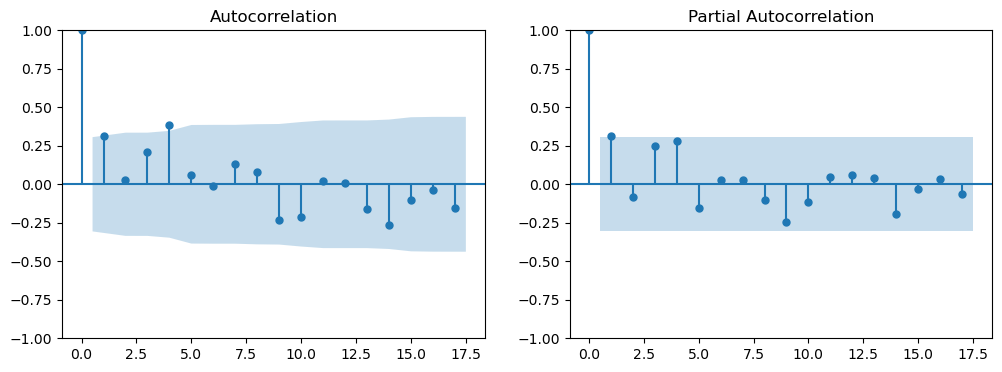

In [31]:
# Plot ACF and PACF of differenced time series
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plot_acf(differenced_series, ax=axes[0])
plot_pacf(differenced_series, ax=axes[1])
plt.show()

##### Here we first calculated the differenced time series from the original time_series, removed any NaN values resulting from the differencing, and then plotted the ACF and PACF to provide insights into the potential order of the AR and MA components in the time series. These plots are useful for determining the appropriate parameters when using the ARIMA model for time series forecasting.

##### Based on the plots, we find that p=1 and q=1. The ACF plot cuts off at lag 1, indicating q=1, and the PACF plot also cuts off at lag 1, indicating p=1. As there is a linear trend in the subscription growth rate, we can set the value of d as 1 to remove the linear trend, making the time series stationary.



Now here’s how to use the ARIMA model on our data:

In [32]:
p, d, q = 1, 1, 1
model = ARIMA(time_series, order=(p, d, q))
results = model.fit()
print(results.summary())

                               SARIMAX Results                                
Dep. Variable:            Subscribers   No. Observations:                   42
Model:                 ARIMA(1, 1, 1)   Log Likelihood                -672.993
Date:                Sun, 14 Jun 2026   AIC                           1351.986
Time:                        01:35:08   BIC                           1357.127
Sample:                    04-01-2013   HQIC                          1353.858
                         - 07-01-2023                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.9997      0.012     80.776      0.000       0.975       1.024
ma.L1         -0.9908      0.221     -4.476      0.000      -1.425      -0.557
sigma2      1.187e+13   1.57e-14   7.57e+26      0.0

In [33]:
future_steps = 5
predictions = results.predict(len(time_series), len(time_series) + future_steps - 1)
predictions = predictions.astype(int)

Now let’s visualize the results of Netflix Subscriptions Forecasting for the next five quarters:

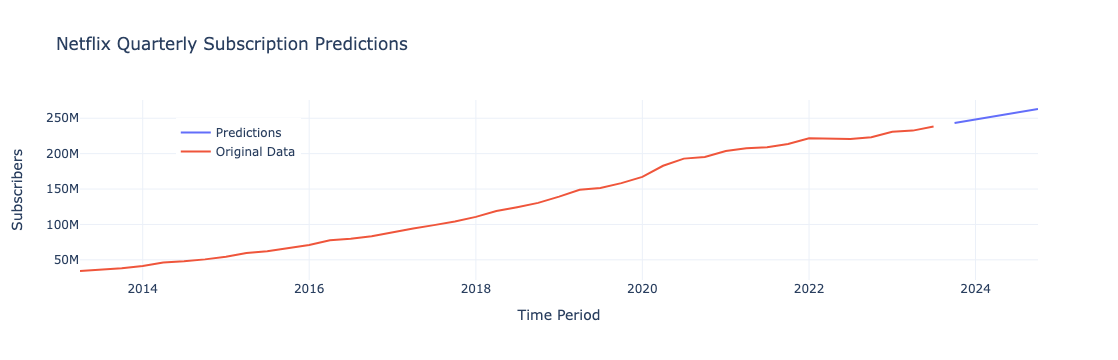

In [34]:
# Create a DataFrame with the original data and predictions
forecast = pd.DataFrame({'Original': time_series, 'Predictions': predictions})

# Plot the original data and predictions
fig = go.Figure()

fig.add_trace(go.Scatter(x=forecast.index, y=forecast['Predictions'],
                         mode='lines', name='Predictions'))

fig.add_trace(go.Scatter(x=forecast.index, y=forecast['Original'],
                         mode='lines', name='Original Data'))

fig.update_layout(title='Netflix Quarterly Subscription Predictions',
                  xaxis_title='Time Period',
                  yaxis_title='Subscribers',
                  legend=dict(x=0.1, y=0.9),
                  showlegend=True)

fig.show()

So this is how you can forecast subscription counts for a given time period using Time Series Forecasting and Python.



### Summary

Using techniques like time series forecasting, Netflix can estimate the expected number of new subscribers in a given time period and better understand the growth potential of their business. It enhances operational efficiency, financial planning, and content strategy, ultimately contributing to their success and growth in the highly competitive streaming industry.

## Smart Subscription Analytics Dashboard

The dashboard below turns the forecasting notebook into a professional subscription growth command center. It combines executive KPIs, trend quality, subscriber momentum, forecast scenarios, growth heatmaps, and decision-ready recommendations that can be reused for Netflix or any subscription business with quarterly subscriber history.

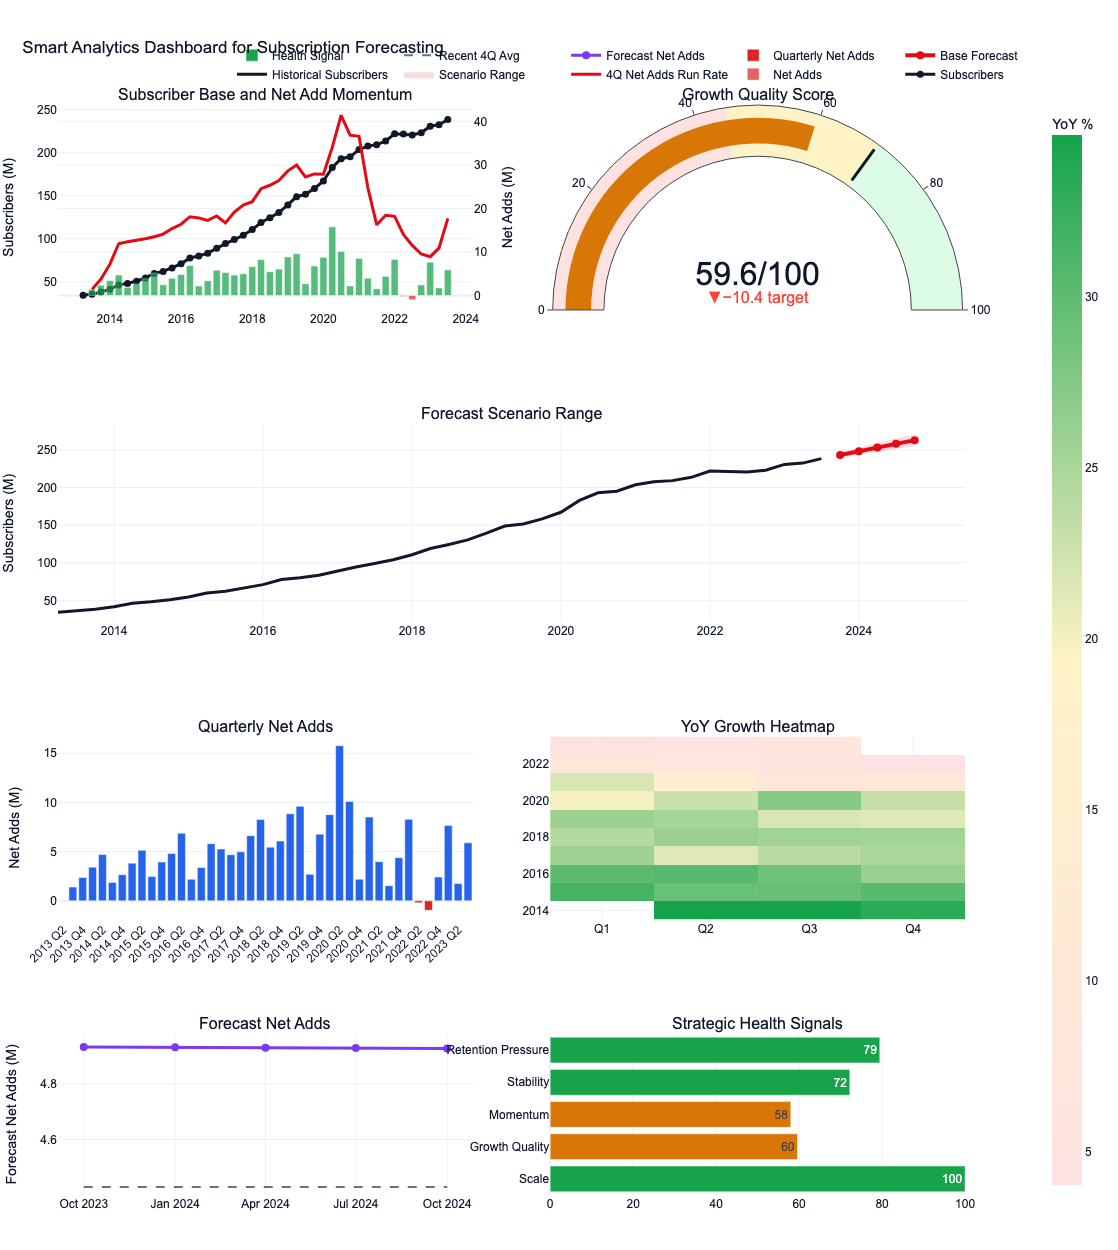

Recommended Action,Business Signal,Priority
Monitor growth consistency,"Subscriber additions are close to the long-term trend, making execution quality and churn control the main levers.",Medium
Investigate YoY softness,Latest YoY growth of 8.03% is below the historical median.,Medium
Reduce quarter-to-quarter volatility,"Recent net adds are less predictable, which can affect revenue planning and content investment timing.",Medium
Use scenario planning for targets,"Bull, base, and bear cases provide a reusable planning range for subscriber, revenue, and capacity forecasts.",Planning


In [35]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from IPython.display import HTML, display

# --- Smart subscription analytics preparation ---
analytics_df = data.copy()
analytics_df['Time Period'] = pd.to_datetime(analytics_df['Time Period'], format='%d/%m/%Y')
analytics_df = analytics_df.sort_values('Time Period').reset_index(drop=True)
analytics_df['Subscribers_M'] = analytics_df['Subscribers'] / 1_000_000
analytics_df['Net_Adds'] = analytics_df['Subscribers'].diff()
analytics_df['Net_Adds_M'] = analytics_df['Net_Adds'] / 1_000_000
analytics_df['QoQ_Growth_%'] = analytics_df['Subscribers'].pct_change() * 100
analytics_df['YoY_Growth_%'] = analytics_df['Subscribers'].pct_change(4) * 100
analytics_df['Rolling_4Q_Net_Adds_M'] = analytics_df['Net_Adds_M'].rolling(4, min_periods=1).sum()
analytics_df['Rolling_4Q_Growth_%'] = analytics_df['QoQ_Growth_%'].rolling(4, min_periods=1).mean()
analytics_df['Year'] = analytics_df['Time Period'].dt.year
analytics_df['Quarter'] = 'Q' + analytics_df['Time Period'].dt.quarter.astype(str)
analytics_df['Quarter_Label'] = analytics_df['Year'].astype(str) + ' ' + analytics_df['Quarter']

latest_row = analytics_df.iloc[-1]
previous_row = analytics_df.iloc[-2]
first_row = analytics_df.iloc[0]
period_years = max((latest_row['Time Period'] - first_row['Time Period']).days / 365.25, 1)
cagr = ((latest_row['Subscribers'] / first_row['Subscribers']) ** (1 / period_years) - 1) * 100
latest_subs_m = latest_row['Subscribers_M']
latest_net_adds_m = latest_row['Net_Adds_M']
latest_qoq = latest_row['QoQ_Growth_%']
latest_yoy = latest_row['YoY_Growth_%']
recent_avg_net_adds_m = analytics_df['Net_Adds_M'].tail(4).mean()
long_avg_net_adds_m = analytics_df['Net_Adds_M'].dropna().mean()
volatility = analytics_df['Net_Adds_M'].tail(8).std()
all_time_added_m = (latest_row['Subscribers'] - first_row['Subscribers']) / 1_000_000

# Reuse notebook forecast if available, but normalize the future dates so the dashboard is clean.
try:
    forecast_values = pd.Series(predictions).astype(float).to_numpy()
    dashboard_steps = len(forecast_values)
except NameError:
    dashboard_steps = 8
    recent_trend = analytics_df['Net_Adds'].tail(4).mean()
    forecast_values = latest_row['Subscribers'] + np.cumsum(np.repeat(recent_trend, dashboard_steps))

future_dates = pd.date_range(
    start=latest_row['Time Period'] + pd.DateOffset(months=3),
    periods=dashboard_steps,
    freq='QS'
)
forecast_df = pd.DataFrame({
    'Time Period': future_dates,
    'Base Forecast': forecast_values
})
forecast_df['Base Forecast_M'] = forecast_df['Base Forecast'] / 1_000_000

scenario_spread = max(float(analytics_df['Net_Adds'].tail(8).std()), float(abs(analytics_df['Net_Adds'].tail(4).mean()) * 0.35), 1_000_000)
step_scale = np.sqrt(np.arange(1, dashboard_steps + 1))
forecast_df['Bull Case_M'] = (forecast_df['Base Forecast'] + scenario_spread * step_scale) / 1_000_000
forecast_df['Bear Case_M'] = np.maximum(0, forecast_df['Base Forecast'] - scenario_spread * step_scale) / 1_000_000
forecast_df['Forecast_Net_Adds_M'] = forecast_df['Base Forecast_M'].diff().fillna(forecast_df['Base Forecast_M'].iloc[0] - latest_subs_m)

momentum_delta = recent_avg_net_adds_m - long_avg_net_adds_m
momentum_label = 'Accelerating' if momentum_delta > 1 else 'Stable' if momentum_delta > -1 else 'Cooling'
momentum_color = '#16a34a' if momentum_label == 'Accelerating' else '#d97706' if momentum_label == 'Stable' else '#dc2626'
retention_pressure = max(0, min(100, 100 - (latest_qoq / max(abs(analytics_df['QoQ_Growth_%'].dropna()).quantile(.75), 1)) * 55))
growth_quality_score = np.nanmean([
    min(max((latest_qoq / max(analytics_df['QoQ_Growth_%'].dropna().quantile(.75), 1)) * 100, 0), 100),
    min(max((recent_avg_net_adds_m / max(long_avg_net_adds_m, 1)) * 70, 0), 100),
    max(0, 100 - min(volatility * 6, 100))
])

def metric_color(value, good=70, watch=45):
    return '#16a34a' if value >= good else '#d97706' if value >= watch else '#dc2626'

kpi_cards = [
    ('Total Subscribers', f'{latest_subs_m:,.1f}M', f'Latest quarter: {latest_row["Quarter_Label"]}', '#e50914'),
    ('Latest Net Adds', f'{latest_net_adds_m:,.2f}M', f'4Q avg: {recent_avg_net_adds_m:,.2f}M', momentum_color),
    ('YoY Growth', f'{latest_yoy:,.2f}%', f'QoQ: {latest_qoq:,.2f}%', '#2563eb'),
    ('Historical CAGR', f'{cagr:,.2f}%', f'Total added: {all_time_added_m:,.1f}M', '#7c3aed'),
]

cards_html = ''.join(
    f"""
    <div style="background:#ffffff;border:1px solid #e5e7eb;border-top:5px solid {color};border-radius:8px;padding:16px 18px;box-shadow:0 10px 28px rgba(15,23,42,.07);">
        <div style="font-size:12px;color:#64748b;text-transform:uppercase;letter-spacing:.08em;font-weight:800;">{title}</div>
        <div style="font-size:31px;line-height:1.05;color:#111827;font-weight:850;margin-top:8px;">{value}</div>
        <div style="font-size:13px;color:#475569;margin-top:8px;">{subtitle}</div>
    </div>
    """
    for title, value, subtitle, color in kpi_cards
)

display(HTML(f"""
<div style="font-family:Inter,Segoe UI,Arial,sans-serif;background:#f8fafc;border:1px solid #e2e8f0;border-radius:10px;padding:18px;margin:14px 0 20px;">
    <div style="display:flex;align-items:flex-end;justify-content:space-between;gap:16px;flex-wrap:wrap;margin-bottom:16px;">
        <div>
            <div style="font-size:13px;color:#e50914;font-weight:850;text-transform:uppercase;letter-spacing:.08em;">Subscription Growth Command Center</div>
            <div style="font-size:27px;color:#0f172a;font-weight:850;margin-top:4px;">Netflix forecasting and executive analytics</div>
        </div>
        <div style="font-size:13px;color:#475569;">Coverage: <b>{analytics_df['Quarter_Label'].iloc[0]}</b> to <b>{analytics_df['Quarter_Label'].iloc[-1]}</b></div>
    </div>
    <div style="display:grid;grid-template-columns:repeat(auto-fit,minmax(195px,1fr));gap:12px;">{cards_html}</div>
</div>
"""))

# --- Professional Plotly dashboard ---
smart_fig = make_subplots(
    rows=4, cols=2,
    specs=[
        [{'secondary_y': True}, {'type': 'indicator'}],
        [{'colspan': 2}, None],
        [{'type': 'bar'}, {'type': 'heatmap'}],
        [{'type': 'scatter'}, {'type': 'bar'}]
    ],
    subplot_titles=(
        'Subscriber Base and Net Add Momentum',
        'Growth Quality Score',
        'Forecast Scenario Range',
        'Quarterly Net Adds',
        'YoY Growth Heatmap',
        'Forecast Net Adds',
        'Strategic Health Signals'
    ),
    vertical_spacing=0.105,
    horizontal_spacing=0.08,
    row_heights=[0.28, 0.27, 0.25, 0.22]
)

smart_fig.add_trace(go.Scatter(
    x=analytics_df['Time Period'], y=analytics_df['Subscribers_M'],
    mode='lines+markers', name='Subscribers',
    line=dict(color='#111827', width=3), marker=dict(size=7)
), row=1, col=1, secondary_y=False)
smart_fig.add_trace(go.Bar(
    x=analytics_df['Time Period'], y=analytics_df['Net_Adds_M'],
    name='Net Adds', marker_color=np.where(analytics_df['Net_Adds_M'] >= 0, '#16a34a', '#dc2626'), opacity=.72
), row=1, col=1, secondary_y=True)
smart_fig.add_trace(go.Scatter(
    x=analytics_df['Time Period'], y=analytics_df['Rolling_4Q_Net_Adds_M'],
    mode='lines', name='4Q Net Adds Run Rate', line=dict(color='#e50914', width=3)
), row=1, col=1, secondary_y=True)

smart_fig.add_trace(go.Indicator(
    mode='gauge+number+delta',
    value=float(growth_quality_score),
    number={'suffix': '/100', 'font': {'size': 32, 'color': '#0f172a'}},
    delta={'reference': 70, 'suffix': ' target'},
    gauge={
        'axis': {'range': [0, 100]},
        'bar': {'color': metric_color(growth_quality_score)},
        'steps': [
            {'range': [0, 45], 'color': '#fee2e2'},
            {'range': [45, 70], 'color': '#fef3c7'},
            {'range': [70, 100], 'color': '#dcfce7'}
        ],
        'threshold': {'line': {'color': '#111827', 'width': 3}, 'thickness': .75, 'value': 70}
    },
    title={'text': f'Momentum: {momentum_label}'}
), row=1, col=2)

smart_fig.add_trace(go.Scatter(
    x=forecast_df['Time Period'], y=forecast_df['Bull Case_M'],
    mode='lines', name='Bull Case', line=dict(width=0), showlegend=False
), row=2, col=1)
smart_fig.add_trace(go.Scatter(
    x=forecast_df['Time Period'], y=forecast_df['Bear Case_M'],
    mode='lines', name='Scenario Range', fill='tonexty', fillcolor='rgba(229,9,20,.14)', line=dict(width=0)
), row=2, col=1)
smart_fig.add_trace(go.Scatter(
    x=analytics_df['Time Period'], y=analytics_df['Subscribers_M'],
    mode='lines', name='Historical Subscribers', line=dict(color='#111827', width=3)
), row=2, col=1)
smart_fig.add_trace(go.Scatter(
    x=forecast_df['Time Period'], y=forecast_df['Base Forecast_M'],
    mode='lines+markers', name='Base Forecast', line=dict(color='#e50914', width=4), marker=dict(size=8)
), row=2, col=1)

smart_fig.add_trace(go.Bar(
    x=analytics_df['Quarter_Label'], y=analytics_df['Net_Adds_M'],
    name='Quarterly Net Adds', marker_color=np.where(analytics_df['Net_Adds_M'] >= 0, '#2563eb', '#dc2626')
), row=3, col=1)

heatmap_df = analytics_df.pivot_table(index='Year', columns='Quarter', values='YoY_Growth_%', aggfunc='mean')
heatmap_df = heatmap_df.reindex(columns=['Q1', 'Q2', 'Q3', 'Q4'])
smart_fig.add_trace(go.Heatmap(
    z=heatmap_df.values,
    x=heatmap_df.columns,
    y=heatmap_df.index,
    colorscale=[[0, '#fee2e2'], [.5, '#fef3c7'], [1, '#16a34a']],
    colorbar=dict(title='YoY %'),
    hovertemplate='Year %{y}<br>%{x}<br>YoY Growth %{z:.2f}%<extra></extra>'
), row=3, col=2)

smart_fig.add_trace(go.Scatter(
    x=forecast_df['Time Period'], y=forecast_df['Forecast_Net_Adds_M'],
    mode='lines+markers', name='Forecast Net Adds', line=dict(color='#7c3aed', width=3), marker=dict(size=8)
), row=4, col=1)
smart_fig.add_trace(go.Scatter(
    x=forecast_df['Time Period'], y=np.repeat(recent_avg_net_adds_m, len(forecast_df)),
    mode='lines', name='Recent 4Q Avg', line=dict(color='#64748b', width=2, dash='dash')
), row=4, col=1)

health_names = ['Scale', 'Growth Quality', 'Momentum', 'Stability', 'Retention Pressure']
health_values = [
    min(latest_subs_m / max(analytics_df['Subscribers_M'].max(), 1) * 100, 100),
    float(growth_quality_score),
    80 if momentum_label == 'Accelerating' else 58 if momentum_label == 'Stable' else 35,
    max(0, 100 - min(volatility * 8, 100)),
    retention_pressure
]
smart_fig.add_trace(go.Bar(
    x=health_values, y=health_names, orientation='h', name='Health Signal',
    marker_color=[metric_color(v) for v in health_values],
    text=[f'{v:.0f}' for v in health_values], textposition='auto'
), row=4, col=2)

smart_fig.update_layout(
    title={'text': 'Smart Analytics Dashboard for Subscription Forecasting', 'x': 0.02, 'xanchor': 'left'},
    template='plotly_white',
    height=1250,
    legend=dict(orientation='h', yanchor='bottom', y=1.015, xanchor='right', x=1),
    margin=dict(l=55, r=45, t=105, b=55),
    font=dict(family='Inter, Segoe UI, Arial, sans-serif', color='#0f172a')
)
smart_fig.update_yaxes(title_text='Subscribers (M)', row=1, col=1, secondary_y=False)
smart_fig.update_yaxes(title_text='Net Adds (M)', row=1, col=1, secondary_y=True)
smart_fig.update_yaxes(title_text='Subscribers (M)', row=2, col=1)
smart_fig.update_yaxes(title_text='Net Adds (M)', row=3, col=1)
smart_fig.update_yaxes(title_text='Forecast Net Adds (M)', row=4, col=1)
smart_fig.update_xaxes(tickangle=-45, row=3, col=1)
smart_fig.update_xaxes(range=[0, 100], row=4, col=2)
smart_fig.show()

# --- Decision-ready analytics table ---
recommendations = []
if momentum_label == 'Cooling':
    recommendations.append(('Rebuild acquisition momentum', 'Recent net adds are below the historical average, so marketing, pricing, content slate, or regional expansion should be reviewed.', 'High'))
elif momentum_label == 'Accelerating':
    recommendations.append(('Protect growth channels', 'Recent net adds are above the long-term average, so the current acquisition channels deserve capacity and budget protection.', 'High'))
else:
    recommendations.append(('Monitor growth consistency', 'Subscriber additions are close to the long-term trend, making execution quality and churn control the main levers.', 'Medium'))

if latest_yoy < analytics_df['YoY_Growth_%'].dropna().median():
    recommendations.append(('Investigate YoY softness', f'Latest YoY growth of {latest_yoy:.2f}% is below the historical median.', 'Medium'))
if volatility > analytics_df['Net_Adds_M'].dropna().std() * .75:
    recommendations.append(('Reduce quarter-to-quarter volatility', 'Recent net adds are less predictable, which can affect revenue planning and content investment timing.', 'Medium'))
recommendations.append(('Use scenario planning for targets', 'Bull, base, and bear cases provide a reusable planning range for subscriber, revenue, and capacity forecasts.', 'Planning'))

rec_df = pd.DataFrame(recommendations, columns=['Recommended Action', 'Business Signal', 'Priority'])
styled_table = rec_df.to_html(index=False, escape=False)
styled_table = styled_table.replace('<table border="1" class="dataframe">', '<table style="width:100%;border-collapse:collapse;font-family:Inter,Segoe UI,Arial,sans-serif;font-size:14px;margin-top:10px;">')
styled_table = styled_table.replace('<th>', '<th style="background:#111827;color:white;text-align:left;padding:10px;border:1px solid #e2e8f0;">')
styled_table = styled_table.replace('<td>', '<td style="padding:10px;border:1px solid #e2e8f0;vertical-align:top;">')
display(HTML(styled_table))
